In [1]:
import os 
from dotenv import load_dotenv
from groq import Groq 
from qdrant_client import QdrantClient
from fastembed import TextEmbedding,SparseTextEmbedding
load_dotenv()
groq_key=os.getenv("GROQ_API_KEY")

/Users/mast/miniconda3/envs/all/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
if not groq_key:
    raise ValueError("GROQ_API_KEY not found in environment variables. Please check ur env files.")

In [4]:
groq_client=Groq(api_key=groq_key)

In [5]:
try:
    qdrant_client = QdrantClient("http://localhost:6333", timeout=5)
    qdrant_client.get_collections()
    print("Connected to Qdrant Docker.")
except Exception:
    print("Could not connect to Qdrant Docker. Using in-memory client.")
    qdrant_client = QdrantClient(":memory:")

Connected to Qdrant Docker.


In [6]:
dense_model=TextEmbedding("BAAI/bge-small-en-v1.5")

In [7]:
sparse_model=SparseTextEmbedding("Qdrant/bm25")

In [8]:
COLLECTION_NAME="cuad_advanced"
print("Environment setup successfully!")

Environment setup successfully!


In [9]:
from typing import List,TypedDict,Optional
class AgentState(TypedDict):

    original_query: str
    current_query: str
    expanded_queries: List[str]
    retrieved_chunks: List[dict]  # Candidate payloads from Qdrant
    reranked_chunks: List[dict]   # Top payloads passed to LLM
    response: str
    retry_count: int
    max_retries: int
    grading_report: dict          # Grades: 'grounded' (bool) and 'relevant' (bool)

In [10]:
from sentence_transformers import CrossEncoder

model_name = "cross-encoder/ms-marco-MiniLM-L-6-v2"

print(f"Loading CrossEncoder model ({model_name})...")
reranker = CrossEncoder(model_name)
print("Reranker loaded successfully!")

Loading CrossEncoder model (cross-encoder/ms-marco-MiniLM-L-6-v2)...


Loading weights: 100%|██████████| 105/105 [00:00<00:00, 8803.64it/s]


Reranker loaded successfully!


In [11]:
from qdrant_client.models import SparseVector


In [19]:
def reciprocal_rank_fusion(results_lists:List[list],k:int=60)->List[dict]:
    """
    Fuses multiple ranked lists using Reciprocal Rank Fusion (RRF).
    De-duplicates entries based on 'chunk_id'.
    """
    rrf_scores={}
    for rank_list in results_lists:
        for idx,hit in enumerate(rank_list):
            payload=hit.payload
            chunk_id=payload["chunk_id"]
            score=1.0/(k+idx+1)
            if chunk_id not in rrf_scores:
                rrf_scores[chunk_id]={
                    "payload":payload,
                    "score":0.0
                }
            rrf_scores[chunk_id]["score"]+=score

    sorted_chunks=sorted(rrf_scores.values(),key=lambda x:x["score"],reverse=True)

    return [item["payload"] for item in sorted_chunks]


In [20]:
def expand_query_node(state:AgentState)->dict:
    query=state["current_query"]
    print(f"\n [Node:expand_query] Expanding Query:'{query}'")
    prompt = f"""You are a legal research search assistant.
    Generate exactly 3 variations of the following search query to help retrieve relevant clauses (such as termination, indemnity, limitation of liability) from a legal contract vector database.
    Generate ONLY the 3 queries, one per line. Do not number them or add any introductory text.

    Original Query: {query}

    
    """

    chat_compilation=groq_client.chat.completions.create(
        messages=[{"role": "user", "content": prompt}],
        model="llama-3.3-70b-versatile",
        temperature=0.2

    )
    response_text=chat_compilation.choices[0].message.content.strip()
    quries=[q.strip() for q in response_text.split("\n")if q.strip()]
    if query not in quries:
        quries.append(query)

    print(f"Generated search variants: {quries}")
    return {"expanded_queries": quries}



In [21]:
def retrieve_node(state:AgentState)->dict:
    queries=state["expanded_queries"]
    print(f"\n[Node: retrieve] Querying Qdrant collection '{COLLECTION_NAME}' for {len(queries)} variations...")
    all_query_results=[]
    for q in queries:
        q_dense=list(dense_model.embed([q]))[0].tolist()
        results=qdrant_client.query_points(
            collection_name=COLLECTION_NAME,
            query=q_dense,
            using="dense-bge",
            limit=10
        )
        all_query_results.append(results.points)

    fused_payloads=reciprocal_rank_fusion(all_query_results)
    print(f"Retrieved and fused {len(fused_payloads)} unique chunks.")
    return {"retrieved_chunks": fused_payloads}

In [22]:
def rerank_node(state:AgentState)->dict:
    original_query=state['original_query']
    candidates=state['retrieved_chunks'][:20]
    print(f"\n[Node: rerank] Reranking {len(candidates)} candidate chunks against original query...")

    if not candidates:
        return {"reranked_chunks":[]}
    pairs = [[original_query, item["chunk_text"]] for item in candidates]
    scores = reranker.predict(pairs)
    
    scored_candidates = []
    for idx, score in enumerate(scores):
        item = candidates[idx]
        item["rerank_score"] = float(score)
        scored_candidates.append(item)
        
    scored_candidates.sort(key=lambda x: x["rerank_score"], reverse=True)
    top_5 = scored_candidates[:5]
    
    print(f"Top reranked chunk score: {top_5[0]['rerank_score']:.4f} | Contract: {top_5[0]['contract_name']}")
    return {"reranked_chunks": top_5}

In [23]:
def generate_node(state:AgentState)-> dict:
    query=state["original_query"]
    contexts=state["reranked_chunks"]
    print(f"\n[Node: generate] Generating response using {len(contexts)} sources...")
    
    formatted_contexts = ""
    for idx, ctx in enumerate(contexts):
        formatted_contexts += f"""---
    SOURCE [{idx + 1}]:
    CONTRACT NAME: {ctx['contract_name']}
    FILE NAME: {ctx['file_name']}
    YEAR: {ctx['year']}
    SECTION: {ctx['section']}
    CONTENT: {ctx['chunk_text']}
    """
        
    prompt = f"""You are an expert corporate lawyer. Answer the query based ONLY on the provided contract sources below.
    Use inline citations when stating facts (e.g. "Fact [SOURCE 1]").
    If the context does not contain enough information to answer the query, reply with: 'INSUFFICIENT_CONTEXT'

    Query: {query}

    Sources:
    {formatted_contexts}
    """
    chat_completion=groq_client.chat.completions.create(
        messages=[{"role": "user", "content": prompt}],
        model="llama-3.3-70b-versatile",
        temperature=0.0
    )
    response = chat_completion.choices[0].message.content.strip()
    print("Response generated successfully.")
    return {"response": response}



In [24]:
def grader_node(state:AgentState)-> dict:
    original_query = state["original_query"]
    response = state["response"]
    contexts = state["reranked_chunks"]
    print(f"\n[Node: grader] Checking response quality...")
    
    if "INSUFFICIENT_CONTEXT" in response:
        print("Grader: LLM flagged insufficient context.")
        return {"grading_report": {"grounded": False, "relevant": False}}
        
    context_text = "\n\n".join([c["chunk_text"] for c in contexts])
    
    grader_prompt = f"""Analyze if the Candidate Response is fully grounded and supported by the Reference Context (legal contracts).
            Also check if it directly answers the User Query.
            Respond in exactly this JSON format:
            {{
            "grounded": true/false,
            "relevant": true/false,
            "explanation": "Short explanation"
            }}

            User Query: {original_query}
            Reference Context: {context_text}
            Candidate Response: {response}"""

    chat_completion = groq_client.chat.completions.create(
        messages=[{"role": "user", "content": grader_prompt}],
        model="llama-3.3-70b-versatile",
        response_format={"type": "json_object"},
        temperature=0.0
    )
    import json
    report = json.loads(chat_completion.choices[0].message.content.strip())
    print(f"Grader report: {report}")
    return {"grading_report": report}

    

In [25]:
def feedback_rewrite_node(state:AgentState)-> dict:
    query = state["current_query"]
    retry = state["retry_count"]
    print(f"\n[Node: feedback_rewrite] Self-Correction triggered (Retry #{retry + 1}). Rewriting search parameters...")
    
    prompt = f"""The previous search query '{query}' did not retrieve enough contract clause information to answer the legal topic.
    Rewrite this query to be broader, using legal synonyms, contract terms, or different search angles to retrieve relevant clauses.
    Output ONLY the rewritten search query. No extra conversational text.

    Query: {query}"""

    chat_completion = groq_client.chat.completions.create(
            messages=[{"role": "user", "content": prompt}],
            model="llama-3.3-70b-versatile",
            temperature=0.3
        )
    
    new_query = chat_completion.choices[0].message.content.strip()
    print(f"New search query: '{new_query}'")
    return {"current_query": new_query, "retry_count": retry + 1}

In [26]:
from langgraph.graph import StateGraph , END

def decide_next_step(state: AgentState) -> str:
    report = state["grading_report"]
    retry_count = state["retry_count"]
    max_retries = state["max_retries"]
    
    if report.get("grounded", False) and report.get("relevant", False):
        print("=== GRADER PASSED: Answer is grounded and relevant! ===")
        return "pass"
    
    if retry_count < max_retries:
        print("=== GRADER FAILED: Initiating self-correction loop! ===")
        return "fail"
    
    print("=== GRADER FAILED: Maximum retry limit reached. Ending process. ===")
    return "max_reached"

In [27]:
workflow=StateGraph(AgentState)

workflow.add_node("expand_query", expand_query_node)
workflow.add_node("retrieve", retrieve_node)
workflow.add_node("rerank", rerank_node)
workflow.add_node("generate", generate_node)
workflow.add_node("grader", grader_node)
workflow.add_node("feedback_rewrite", feedback_rewrite_node)

workflow.set_entry_point("expand_query")
workflow.add_edge("expand_query", "retrieve")
workflow.add_edge("retrieve", "rerank")
workflow.add_edge("rerank", "generate")
workflow.add_edge("generate", "grader")

workflow.add_conditional_edges(
    "grader",
    decide_next_step,
    {
        "pass": END,
        "fail": "feedback_rewrite",
        "max_reached": END
    }
)
workflow.add_edge("feedback_rewrite", "expand_query")

app = workflow.compile()
print("LangGraph Agent compiled successfully!")

LangGraph Agent compiled successfully!


In [28]:
inputs = {
    "original_query": "What is the liability cap under the Applied Materials contract?",
    "current_query": "What is the liability cap under the Applied Materials contract?",
    "expanded_queries": [],
    "retrieved_chunks": [],
    "reranked_chunks": [],
    "response": "",
    "retry_count": 0,
    "max_retries": 2,
    "grading_report": {}
}

print("Starting Agent Thread...")
result = app.invoke(inputs)

print("\n================ FINAL RESPONSE ================")
print(result["response"])

Starting Agent Thread...

 [Node:expand_query] Expanding Query:'What is the liability cap under the Applied Materials contract?'
Generated search variants: ['What are the limitation of liability clauses in the Applied Materials agreement?', 'What is the indemnification provision in the contract between Applied Materials and its partners?', 'What are the terms of termination and liability caps specified in the Applied Materials contract documents?', 'What is the liability cap under the Applied Materials contract?']

[Node: retrieve] Querying Qdrant collection 'cuad_advanced' for 4 variations...
Retrieved and fused 3 unique chunks.

[Node: rerank] Reranking 3 candidate chunks against original query...
Top reranked chunk score: -4.3892 | Contract: Applied Materials Credit Agreement

[Node: generate] Generating response using 3 sources...
Response generated successfully.

[Node: grader] Checking response quality...
Grader report: {'grounded': True, 'relevant': True, 'explanation': 'The Can

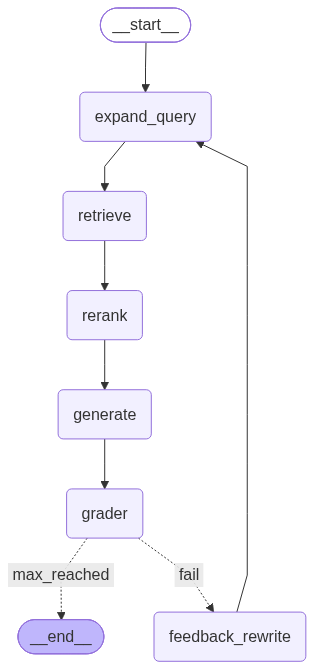

In [29]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))